# Self-Supervised Learning: Rotation Prediction Walkthrough

> **Personal Note:** When I opened the file, the implementation seemed to be already complete? Rather than re-submitting code that was already written, this notebook instead serves as a step by step of what the code does, why each piece works, and what the intermediate outputs look like at each stage.

This is a minimal self-supervised learning example where a linear model learns to predict how an image was rotated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1: The Original Image
We start with a tiny 4×4 image `x0`. In this case we are building a simple table to mock as an example of an image

In [ ]:
x0 = np.array([
    [0,0,0,0],
    [0,1,0,0],
    [0,0,2,0],
    [0,0,0,0],
], dtype=np.float32)

print("Original image x0:")
print(x0)

## Step 2, Build X Four Rotations of x0
I created 4 versions of the image by rotating 0degrees, 90degrees, 180degrees, and 270degrees, then flatten each into a 16-element vector.

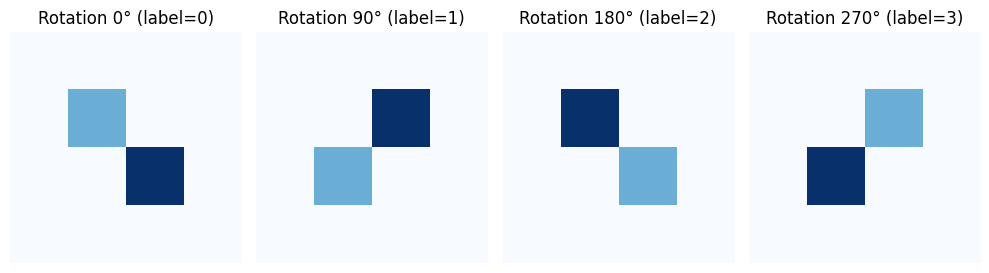

X shape: (4, 16)   (4 images x 16 pixels each)
y (labels): [0 1 2 3]


In [3]:
labels = ['0°', '90°', '180°', '270°']

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for k in range(4):
    if 'x0' not in globals():
        x0 = np.array([
            [0, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 0, 2, 0],
            [0, 0, 0, 0],
        ], dtype=np.float32)
    rotated = np.rot90(x0, k)
    axes[k].imshow(rotated, cmap='Blues', vmin=0, vmax=2)
    axes[k].set_title(f'Rotation {labels[k]} (label={k})')
    axes[k].axis('off')
plt.tight_layout()
plt.show()

X = np.stack([np.rot90(x0, k).reshape(-1) for k in range(4)], axis=0)
y = np.array([0, 1, 2, 3])

print("X shape:", X.shape, "  (4 images x 16 pixels each)")
print("y (labels):", y)

## Step 3, Initialize the Linear Model
The code use a linear model: `logits = X @ W + b`  
- W shape: (16, 4) is to map each pixel to 4 class scores  
- b shape: (4,) is for bias per class

In [4]:
rng = np.random.default_rng(0)
W = (0.01 * rng.normal(size=(16, 4))).astype(np.float32)
b = np.zeros(4, dtype=np.float32)

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: (16, 4)
b shape: (4,)


## Step 4, Forward Pass & Logits & Softmax Probabilities
The softmax converts raw scores into probabilities that sum to 1 per image:

So We subtract the max for numerical stability.

In [5]:
logits = X @ W + b
print("Logits (raw scores):")
print(np.round(logits, 4))

# Softmax
logits -= logits.max(axis=1, keepdims=True)
P = np.exp(logits)
P /= P.sum(axis=1, keepdims=True)

print("\nP (softmax probabilities) — each row sums to 1:")
print(np.round(P, 4))
print("\nRow sums (should all be 1.0):", P.sum(axis=1).round(4))

Logits (raw scores):
[[-0.0265  0.0439  0.0203  0.0191]
 [ 0.0115  0.0006 -0.007  -0.0035]
 [-0.0152  0.0425  0.0002  0.0148]
 [-0.004  -0.0017  0.0082  0.0207]]

P (softmax probabilities) — each row sums to 1:
[[0.24   0.2575 0.2514 0.2512]
 [0.2528 0.25   0.2481 0.249 ]
 [0.2436 0.258  0.2474 0.251 ]
 [0.2475 0.2481 0.2506 0.2537]]

Row sums (should all be 1.0): [1. 1. 1. 1.]


## Step 5: Cross-Entropy Loss
The loss measures how wrong the predictions are (it was one of the first things I learnt in this class!)

In [6]:
loss = -np.log(P[np.arange(4), y] + 1e-12).mean()
print("Correct class probabilities:", P[np.arange(4), y].round(4))
print("Loss before SGD step:", float(loss))

Correct class probabilities: [0.24   0.25   0.2474 0.2537]
Loss before SGD step: 1.3954671621322632


## Step 6 One-Hot Encode Y
Now we convert the labels into a matrix `Y` where each row has a single `1.0` at the correct class index.

In [7]:
Y = np.zeros_like(P)
Y[np.arange(4), y] = 1.0

print("One-hot Y:")
print(Y)

One-hot Y:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Step 7 SGD Update
We compute gradients and take one gradient descent step.

- Gradient of loss w.r.t. logits: `(P - Y) / N`
- Gradient w.r.t. W: `X.T @ dlogits`
- Gradient w.r.t. b: `dlogits.sum(axis=0)`

In [8]:
dlogits = (P - Y) / 4.0
dW = X.T @ dlogits
db = dlogits.sum(axis=0)

lr = 0.5
W -= lr * dW
b -= lr * db

print("One SGD step taken (lr=0.5)")

One SGD step taken (lr=0.5)


## Step 8, the Loss After SGD Step

In [9]:
logits = X @ W + b
logits -= logits.max(axis=1, keepdims=True)
P = np.exp(logits)
P /= P.sum(axis=1, keepdims=True)

loss_after = -np.log(P[np.arange(4), y] + 1e-12).mean()
print("Loss before:", float(loss))
print("Loss after: ", float(loss_after))
print(f"Improvement: {float(loss) - float(loss_after):.4f}")

Loss before: 1.3954671621322632
Loss after:  1.08787202835083
Improvement: 0.3076


## Step 9, Training Over Multiple Steps
Now we can run 100 SGD steps and watch the loss decrease!

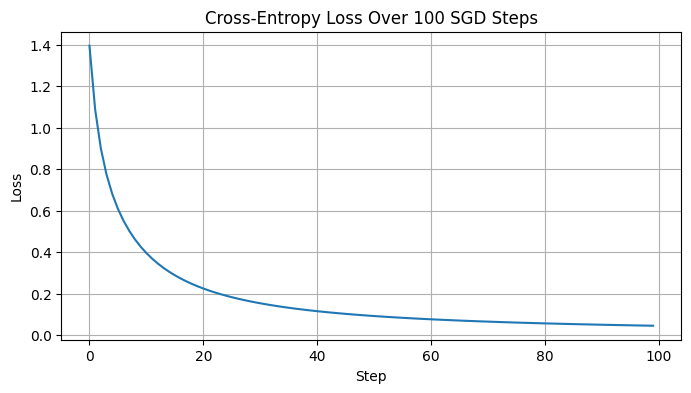

Final loss: 0.0458


In [10]:

rng = np.random.default_rng(0)
W = (0.01 * rng.normal(size=(16, 4))).astype(np.float32)
b = np.zeros(4, dtype=np.float32)

losses = []
for step in range(100):
    logits = X @ W + b
    logits -= logits.max(axis=1, keepdims=True)
    P = np.exp(logits)
    P /= P.sum(axis=1, keepdims=True)

    loss = -np.log(P[np.arange(4), y] + 1e-12).mean()
    losses.append(float(loss))

    Y = np.zeros_like(P)
    Y[np.arange(4), y] = 1.0
    dlogits = (P - Y) / 4.0
    W -= 0.5 * (X.T @ dlogits)
    b -= 0.5 * dlogits.sum(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Cross-Entropy Loss Over 100 SGD Steps')
plt.grid(True)
plt.show()

print(f"Final loss: {losses[-1]:.4f}")